Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate,GridSearchCV, cross_val_predict
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns

Data loading

In [ ]:
df =pd.read_csv("/content/Customer-Churn-Records.csv")

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


Data Exploration

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

| Column               | Meaning                                             |
| -------------------- | --------------------------------------------------- |
| `RowNumber`          | Row/index number from the original dataset          |
| `CustomerId`         | Unique ID assigned to each customer                 |
| `Surname`            | Customer's last name                                |
| `CreditScore`        | Customer's credit score                             |
| `Geography`          | Customer's country/region                           |
| `Gender`             | Customer's gender                                   |
| `Age`                | Customer's age                                      |
| `Tenure`             | Number of years the customer has been with the bank |
| `Balance`            | Customer's bank account balance                     |
| `NumOfProducts`      | Number of banking products the customer uses        |
| `HasCrCard`          | Whether the customer has a credit card              |
| `IsActiveMember`     | Whether the customer is an active member            |
| `EstimatedSalary`    | Estimated annual salary of the customer             |
| `Exited`             | Whether the customer left the bank                  |
| `Complain`           | Whether the customer made a complaint               |
| `Satisfaction Score` | Customer satisfaction rating                        |
| `Card Type`          | Type of bank card the customer has                  |
| `Point Earned`       | Loyalty/reward points earned by the customer        |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [ ]:
df.isna().sum() #no missing values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.duplicated().sum() #no duplicates

np.int64(0)

In [ ]:
df["CustomerId"].duplicated().sum() #no repeated id to ensure that those are different persons with different data

np.int64(0)

In [ ]:
for col in df:
  print(col)
  print(df[col].unique())
  print("*"*20)

#no hidden missings
#categorical data needs encoding

RowNumber
[    1     2     3 ...  9998  9999 10000]
********************
CustomerId
[15634602 15647311 15619304 ... 15584532 15682355 15628319]
********************
Surname
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
********************
CreditScore
[619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771

In [ ]:
df = df.drop(columns=['RowNumber',"CustomerId","Surname"]) #drop identifiers

In [ ]:
df["Exited"].value_counts() #It's imbalanced

,count
Exited,
0,7962
1,2038


##Visualizations

CreditScore


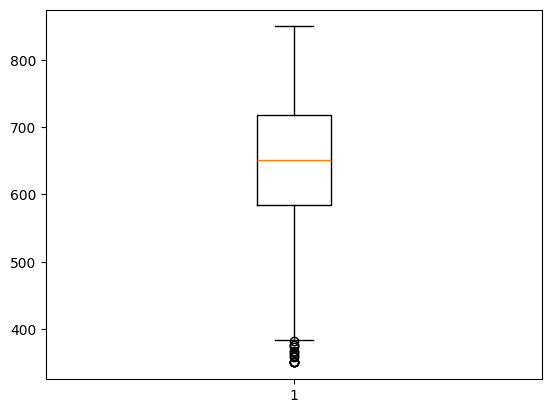

********************
Age


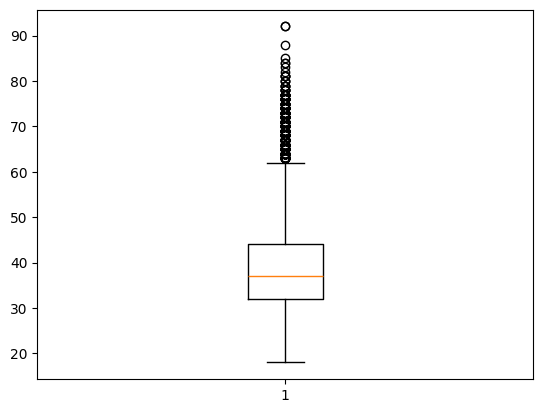

********************
Tenure


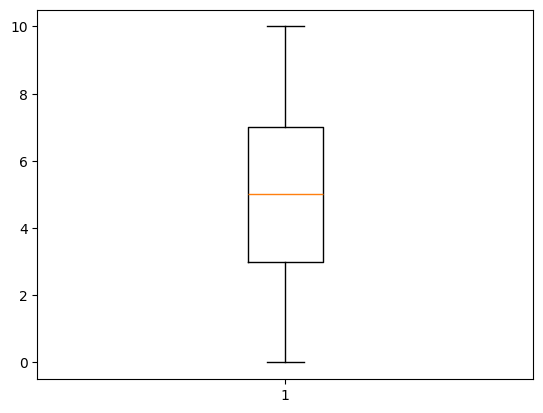

********************
Balance


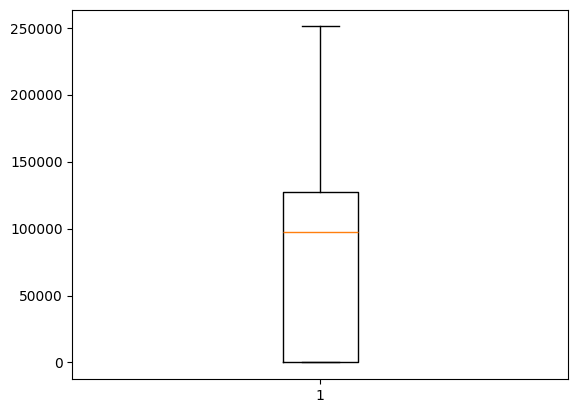

********************
NumOfProducts


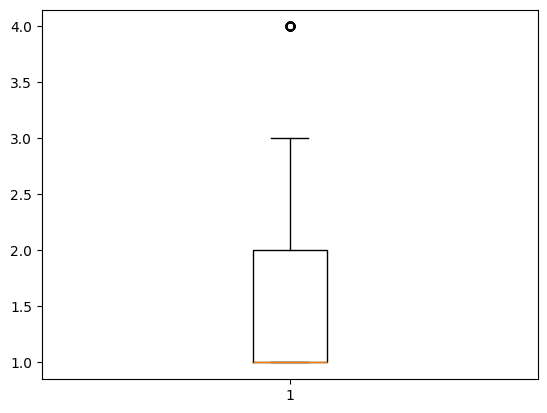

********************
HasCrCard


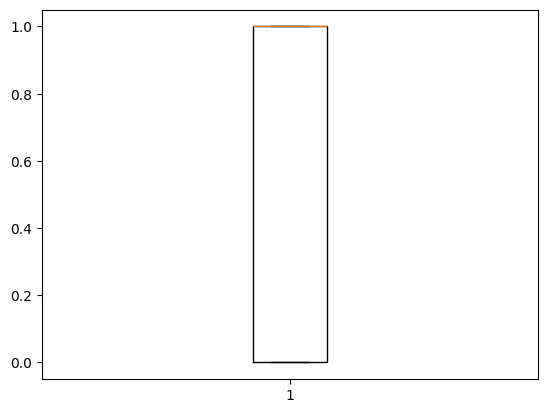

********************
IsActiveMember


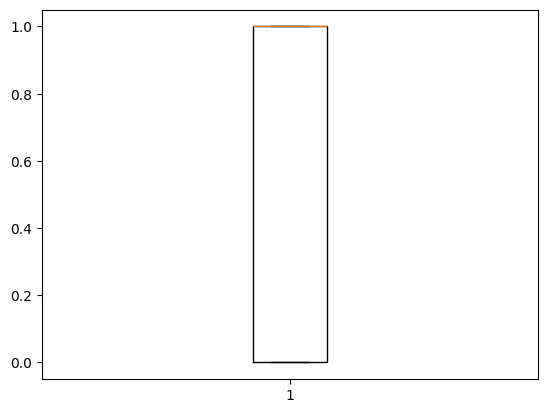

********************
EstimatedSalary


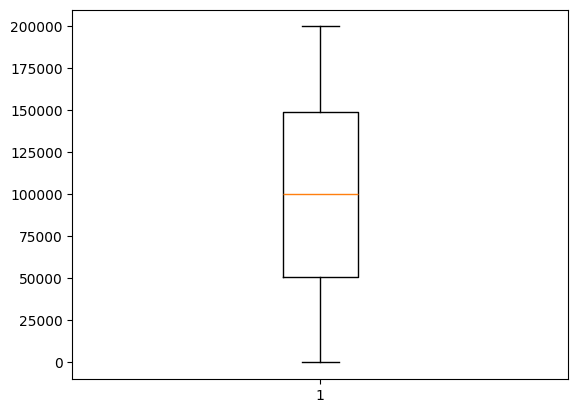

********************
Exited


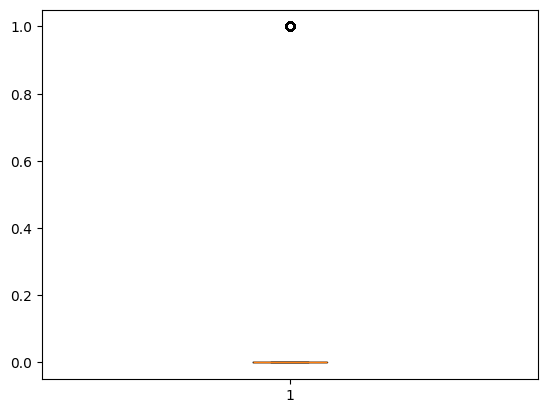

********************
Satisfaction Score


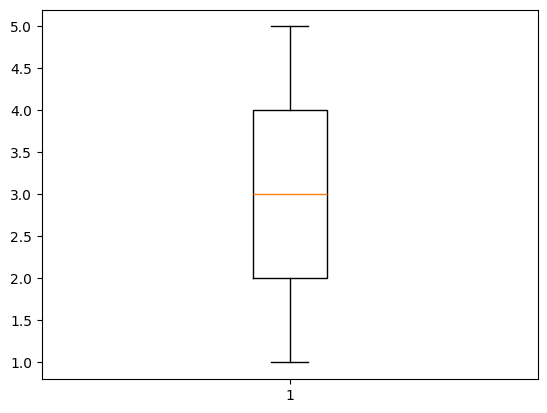

********************
Point Earned


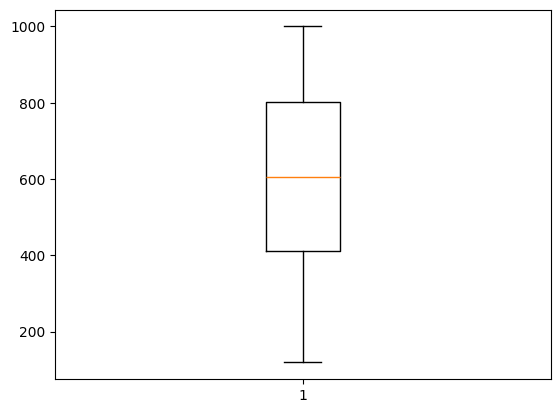

********************


In [ ]:
for col in df.columns:
    if df[col].dtype != bool and df[col].dtype!=object:
        print(col)
        plt.boxplot(df[col])
        plt.show()
        print("*" * 20)

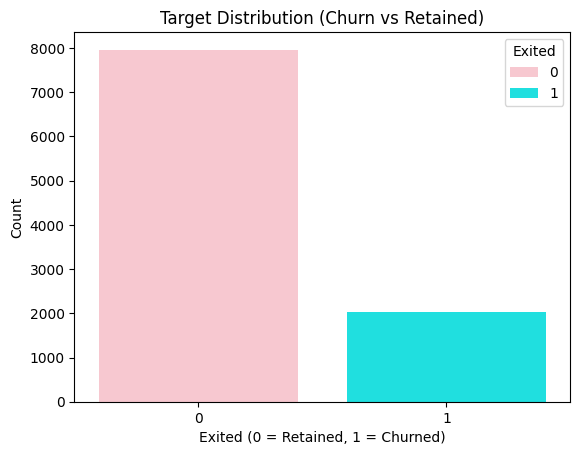

In [ ]:
sns.countplot(data=df, x='Exited',hue='Exited', palette=['pink', 'cyan'])
plt.title('Target Distribution (Churn vs Retained)')
plt.xlabel('Exited (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.show()

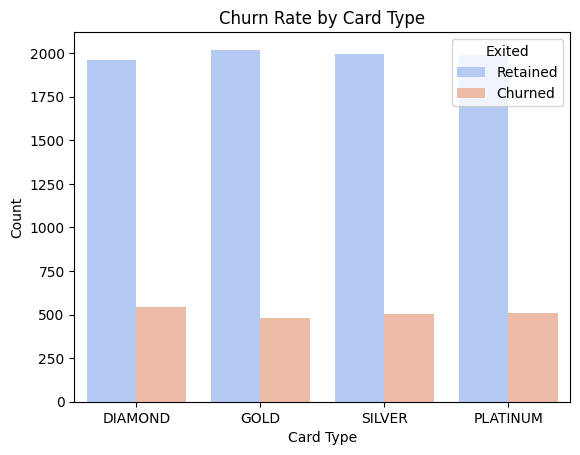

In [ ]:
sns.countplot(data=df, x='Card Type', hue='Exited', palette='coolwarm')
plt.title('Churn Rate by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Retained', 'Churned'])
plt.show()

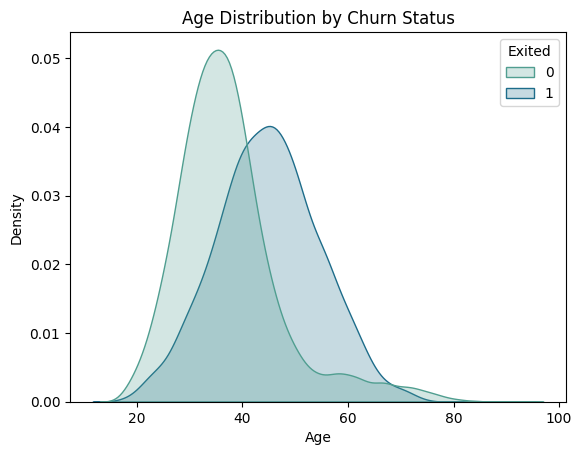

In [ ]:
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, common_norm=False, palette='crest')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.show()

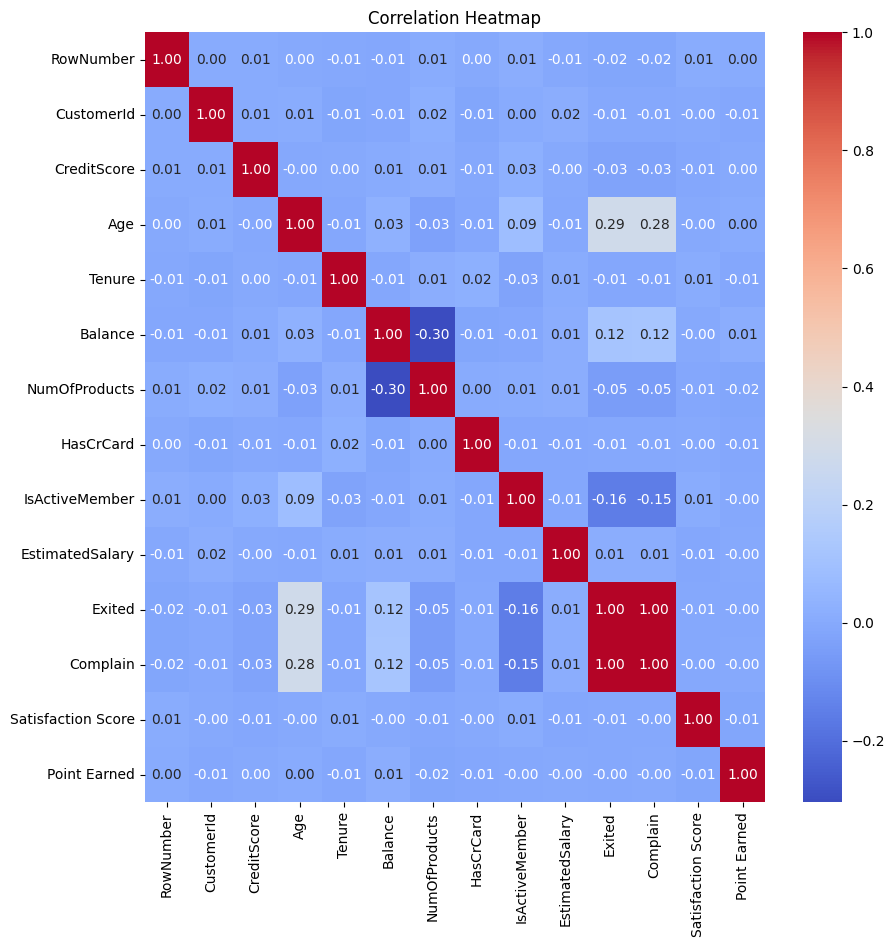

In [ ]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

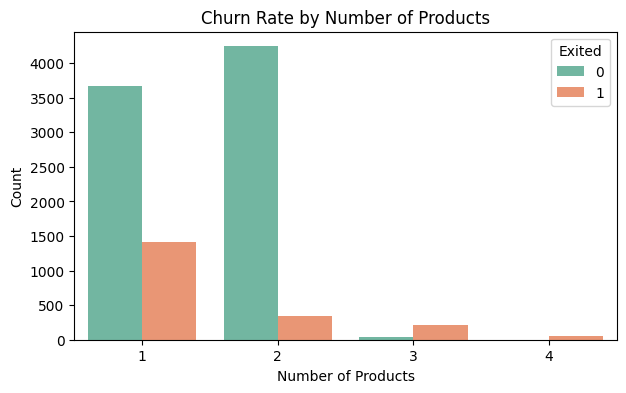

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='NumOfProducts', hue='Exited', palette='Set2')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.show()

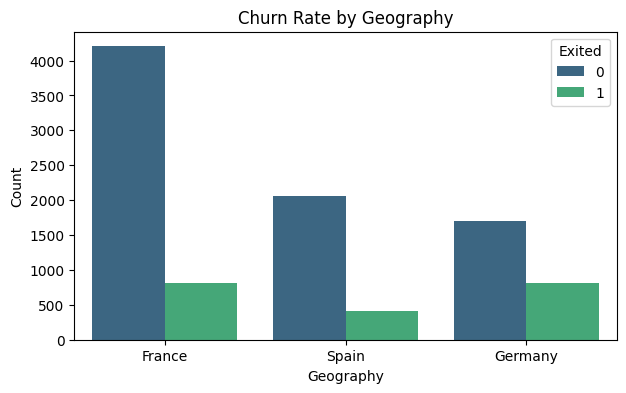

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Geography', hue='Exited', palette='viridis')
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

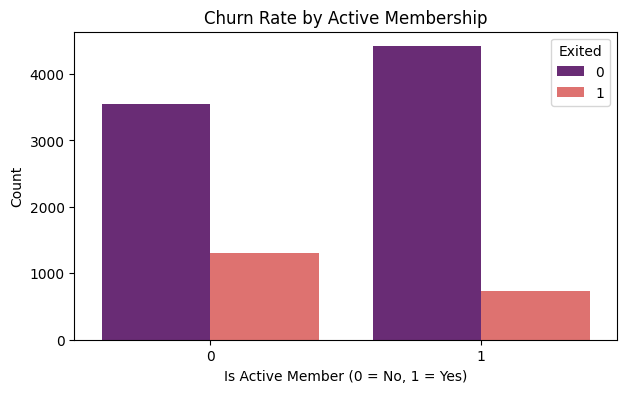

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='IsActiveMember', hue='Exited', palette='magma')
plt.title('Churn Rate by Active Membership')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

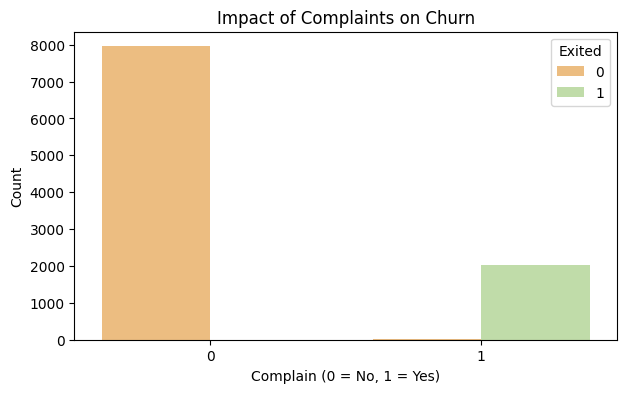

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Complain', hue='Exited', palette='Spectral')
plt.title('Impact of Complaints on Churn')
plt.xlabel('Complain (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

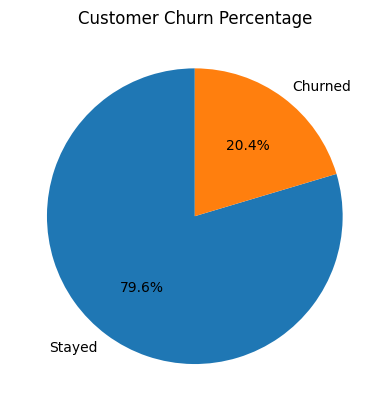

In [ ]:
plt.pie(
    df["Exited"].value_counts(),
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Churn Percentage")
plt.show()

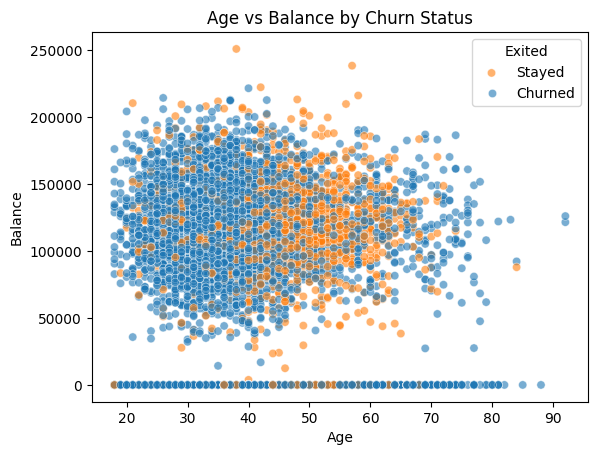

In [ ]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Balance",
    hue="Exited",
    alpha=0.6
)

plt.title("Age vs Balance by Churn Status")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.legend(
    title="Exited",
    labels=["Stayed", "Churned"]
)

plt.show()

investigate the relationship between the features and Exited

In [ ]:
pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

Exited,0,1
Geography,,
France,83.825289,16.174711
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [ ]:
pd.crosstab(df["Card Type"], df["Exited"], normalize="index") * 100

Exited,0,1
Card Type,,
DIAMOND,78.220981,21.779019
GOLD,80.735412,19.264588
PLATINUM,79.639279,20.360721
SILVER,79.887821,20.112179


In [ ]:
pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="index") * 100

Exited,0,1
IsActiveMember,,
0,73.128480,26.871520
1,85.730926,14.269074


In [ ]:
pd.crosstab(df["Complain"], df["Exited"], normalize="index") * 100  #indicates data leakage

Exited,0,1
Complain,,
0,99.949723,0.050277
1,0.489237,99.510763


In [ ]:
df = df.drop(columns='Complain') #drop Complain to avoid data leakage

Encoding

In [ ]:
df_encoded=df.copy()

In [ ]:
df_encoded = pd.get_dummies(df_encoded,columns=['Geography',"Gender"],drop_first=True)

In [ ]:
df_encoded['Card Type'] = df_encoded['Card Type'].map ({"DIAMOND":4,"PLATINUM":3,"GOLD":2,"SILVER":1})

In [ ]:
df_encoded

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,2,4,464,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,3,4,456,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,4,377,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,5,2,350,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,5,2,425,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,4,300,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,5,3,771,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,3,1,564,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,2,2,339,True,False,True


Data splitting and seperation

In [ ]:
x=df_encoded.drop("Exited",axis=1)

In [ ]:
y=df_encoded["Exited"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

Load model for testing

In [ ]:
def model_TrainingAndEvaluation(model,X_train, y_train,X_test,y_test):
      model.fit(X_train, y_train)
      y_pred_test = model.predict(X_test)
      y_pred_train=model.predict(X_train)
      acc_test = accuracy_score(y_test, y_pred_test)
      acc_train=accuracy_score(y_train, y_pred_train)
      clas= classification_report(y_test, y_pred_test)
      print(f"Train Accuracy: {acc_train}")
      print(f"Test Accuracy: {acc_test}")
      print(f"Classification_report: \n{clas}")
      print("*"*40)

In [ ]:
#um gonna use logisic regression to evaluate balancing method
model = LogisticRegression(max_iter=2000)

Scalling

In [ ]:
model_TrainingAndEvaluation(model,X_train, y_train,X_test,y_test)

Train Accuracy: 0.812
Test Accuracy: 0.8092
Classification_report: 
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1991
           1       0.60      0.18      0.28       509

    accuracy                           0.81      2500
   macro avg       0.71      0.58      0.59      2500
weighted avg       0.78      0.81      0.77      2500

****************************************


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_TrainingAndEvaluation(model,X_train_scaled, y_train,X_test_scaled,y_test)

Train Accuracy: 0.8117333333333333
Test Accuracy: 0.8088
Classification_report: 
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1991
           1       0.59      0.19      0.29       509

    accuracy                           0.81      2500
   macro avg       0.71      0.58      0.59      2500
weighted avg       0.78      0.81      0.77      2500

****************************************


Handelling Data Imbalance

In [ ]:
print(y_train.value_counts())

Exited
0    5971
1    1529
Name: count, dtype: int64


In [ ]:
#using smote
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,y_train
)

In [ ]:
print(y_train_smote.value_counts())

Exited
0    5971
1    5971
Name: count, dtype: int64


In [ ]:
X_train_scaled_smote = scaler.fit_transform(X_train_smote)

In [ ]:
model_TrainingAndEvaluation(model,X_train_scaled_smote, y_train_smote,X_test_scaled,y_test)

Train Accuracy: 0.7761681460391894
Test Accuracy: 0.62
Classification_report: 
              precision    recall  f1-score   support

           0       0.91      0.58      0.71      1991
           1       0.32      0.76      0.45       509

    accuracy                           0.62      2500
   macro avg       0.61      0.67      0.58      2500
weighted avg       0.79      0.62      0.66      2500

****************************************


In [ ]:
resampler = RandomUnderSampler()

X_train_RandomUnderSampler , y_train_RandomUnderSampler = resampler.fit_resample(X_train_scaled,y_train)

print(pd.Series(y_train_RandomUnderSampler).value_counts())

Exited
0    1529
1    1529
Name: count, dtype: int64


In [ ]:
model_TrainingAndEvaluation(model,X_train_RandomUnderSampler, y_train_RandomUnderSampler ,X_test_scaled,y_test)

Train Accuracy: 0.710595160235448
Test Accuracy: 0.7212
Classification_report: 
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1991
           1       0.40      0.72      0.51       509

    accuracy                           0.72      2500
   macro avg       0.65      0.72      0.66      2500
weighted avg       0.81      0.72      0.75      2500

****************************************


In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(
    X_train_scaled,
    y_train
)

model_TrainingAndEvaluation(model,X_train_over, y_train_over ,X_test_scaled,y_test)

Train Accuracy: 0.699799028638419
Test Accuracy: 0.7176
Classification_report: 
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1991
           1       0.39      0.73      0.51       509

    accuracy                           0.72      2500
   macro avg       0.65      0.72      0.66      2500
weighted avg       0.81      0.72      0.74      2500

****************************************


Cross validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
models = {
    "No Balancing": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Oversampling": Pipeline([
        ("scaler", StandardScaler()),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Undersampling": Pipeline([
        ("scaler", StandardScaler()),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=1000))
    ])
}

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = {}

for name, pipeline in models.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

In [ ]:


results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
No Balancing,0.810267,0.601353,0.207342,0.308236,0.759414
SMOTE,0.707867,0.378674,0.676901,0.485522,0.762354
Random Oversampling,0.707200,0.378938,0.684764,0.487783,0.762055
Random Undersampling,0.703467,0.375869,0.688679,0.486132,0.761442


In [ ]:
#SMOTE achieved the highest F1-score while maintaining strong recall so um gonna continue with it.

Feature selection

In [ ]:
model_TrainingAndEvaluation(model,X_train_scaled_smote, y_train_smote,X_test_scaled,y_test)

Train Accuracy: 0.7761681460391894
Test Accuracy: 0.62
Classification_report: 
              precision    recall  f1-score   support

           0       0.91      0.58      0.71      1991
           1       0.32      0.76      0.45       509

    accuracy                           0.62      2500
   macro avg       0.61      0.67      0.58      2500
weighted avg       0.79      0.62      0.66      2500

****************************************


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled_smote,y_train_smote)

feature_importance = rf.feature_importances_

names = X_train.columns

df_features = pd.DataFrame({
    "names": names,
    "importance": feature_importance
})

df_features.sort_values(
    by="importance",
    ascending=False,
    inplace=True
)

df_features

,names,importance
1,Age,0.193628
6,IsActiveMember,0.100077
3,Balance,0.098576
4,NumOfProducts,0.092792
7,EstimatedSalary,0.085363
10,Point Earned,0.084966
0,CreditScore,0.080356
11,Geography_Germany,0.069660
2,Tenure,0.054625
8,Satisfaction Score,0.048703


In [ ]:
logistic = LogisticRegression(max_iter=2000)

In [ ]:
X_train_scaled_smote_df = pd.DataFrame(
    X_train_scaled_smote,
    columns=X_train.columns
)

X_test_scaled_df = pd.DataFrame(
   X_test_scaled,
    columns=X_test.columns
)

In [ ]:
for i in range(10, 16):

  top_sel_features = df_features["names"].head(i).tolist()

  X_train_sel = X_train_scaled_smote_df[top_sel_features]
  X_test_sel = X_test_scaled_df[top_sel_features]
  print("Number of selected features: ",i)
  model_TrainingAndEvaluation(logistic,X_train_sel, y_train_smote,X_test_sel, y_test)

Number of selected features:  10
Train Accuracy: 0.7602579132473622
Test Accuracy: 0.6132
Classification_report: 
              precision    recall  f1-score   support

           0       0.90      0.58      0.70      1991
           1       0.31      0.75      0.44       509

    accuracy                           0.61      2500
   macro avg       0.61      0.67      0.57      2500
weighted avg       0.78      0.61      0.65      2500

****************************************
Number of selected features:  11
Train Accuracy: 0.7616814603918941
Test Accuracy: 0.6228
Classification_report: 
              precision    recall  f1-score   support

           0       0.91      0.59      0.71      1991
           1       0.32      0.76      0.45       509

    accuracy                           0.62      2500
   macro avg       0.61      0.67      0.58      2500
weighted avg       0.79      0.62      0.66      2500

****************************************
Number of selected features:  12
Tra

Model training

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True,random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = {}

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

In [ ]:
results_df = pd.DataFrame(results).T

results_df.sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.847867,0.635841,0.593166,0.613506,0.857791
Random Forest,0.848267,0.649432,0.556554,0.599241,0.849520
AdaBoost,0.789067,0.489056,0.706339,0.577617,0.834826
SVM,0.794133,0.496458,0.678189,0.573134,0.823439
Naive Bayes,0.725867,0.397596,0.663836,0.496822,0.780862
Decision Tree,0.770133,0.447245,0.544147,0.490863,0.686075
Logistic Regression,0.707867,0.378674,0.676901,0.485522,0.762354
KNN,0.718533,0.385822,0.642889,0.482230,0.745191


##hyperparameter tuning

GradientBoost tuning

In [ ]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [ ]:
param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1, 0.2],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100, 150]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best CV F1:
0.6181158992064404


In [ ]:
best_gb = grid_search.best_estimator_

Random Forest Tuning

In [ ]:
#Trying with Random Forest
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

In [ ]:
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest CV F1:")
print(rf_grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV F1:
0.616901645629339


Adaboost Tuning

In [ ]:
ada_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", AdaBoostClassifier(random_state=42))
])

In [ ]:
ada_param_grid = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

In [ ]:
ada_grid_search = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

ada_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        AdaBoostClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
                         'model__n_estimators': [50, 100, 200, 300]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(ada_grid_search.best_params_)

print("\nBest CV F1:")
print(ada_grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.5, 'model__n_estimators': 300}

Best CV F1:
0.5901611207376473


Cross Validation for the best Gradient Boosting pipeline

In [ ]:
final_scores = cross_validate(
    best_gb,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    print(
        f"{metric}: "
        f"{final_scores['test_' + metric].mean():.4f}"
    )

accuracy: 0.8417
precision: 0.6083
recall: 0.6285
f1: 0.6181
roc_auc: 0.8559


Trying XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", xgb_model)
])

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
xgb_scores = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

xgb_results = {
    "Accuracy": xgb_scores["test_accuracy"].mean(),
    "Precision": xgb_scores["test_precision"].mean(),
    "Recall": xgb_scores["test_recall"].mean(),
    "F1": xgb_scores["test_f1"].mean(),
    "ROC-AUC": xgb_scores["test_roc_auc"].mean()
}

xgb_results

{'Accuracy': np.float64(0.8518666666666667),
 'Precision': np.float64(0.6601065498368281),
 'Recall': np.float64(0.5643951569698917),
 'F1': np.float64(0.6083676598268506),
 'ROC-AUC': np.float64(0.8592449074504647)}

In [ ]:
param_grid_xgb = {
    "model__n_estimators": [100, 150, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid_xgb,
    n_iter=50,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_cate...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 150, 200,
                                                                300, 500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

Best CV F1:
0.6176899483786625


In [ ]:
best_xgb = random_search.best_estimator_

Train Accuracy: 0.8531
Test Accuracy: 0.8420
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1991
           1       0.60      0.66      0.63       509

    accuracy                           0.84      2500
   macro avg       0.76      0.77      0.76      2500
weighted avg       0.85      0.84      0.84      2500

ROC-AUC: 0.8693


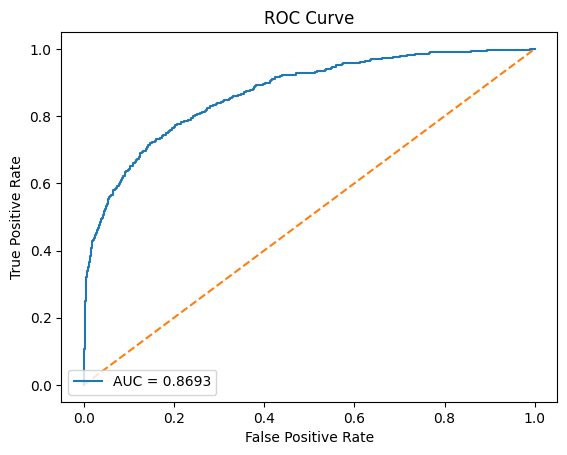

In [ ]:
model_TrainingAndEvaluation2(
    best_xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

Gradient Boosting is still the best

##Final Report

In [ ]:
def model_TrainingAndEvaluation2(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)


    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    y_prob_test = model.predict_proba(X_test)[:, 1]
    acc_test = accuracy_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    clas = classification_report(y_test, y_pred_test)
    roc_accuracy = roc_auc_score(y_test, y_prob_test)

    print(f"Train Accuracy: {acc_train:.4f}")
    print(f"Test Accuracy: {acc_test:.4f}")
    print(f"Classification Report:\n{clas}")
    print(f"ROC-AUC: {roc_accuracy:.4f}")
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

    plt.plot(fpr, tpr, label=f"AUC = {roc_accuracy:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower left")
    plt.show()

Train Accuracy: 0.8541
Test Accuracy: 0.8548
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1991
           1       0.65      0.63      0.64       509

    accuracy                           0.85      2500
   macro avg       0.78      0.77      0.77      2500
weighted avg       0.85      0.85      0.85      2500

ROC-AUC: 0.8685


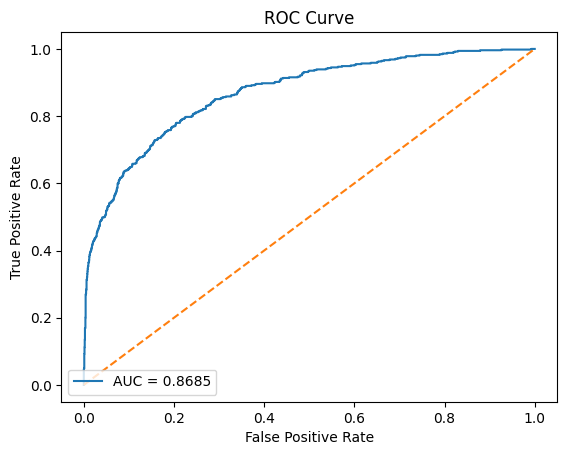

In [ ]:
model_TrainingAndEvaluation2(
    best_gb,
    X_train,
    y_train,
    X_test,
    y_test
)